# Flujo de trabajo en ML y evaluación de modelos

> Cómo se organiza un proyecto de aprendizaje automático (CRISP-DM) y cómo se evalúa un modelo de forma honesta: particiones, validación cruzada, búsqueda de hiperparámetros, sobreajuste y métricas de clasificación y regresión.
>
> **Relacionado:** [Limpieza de datos](../03-preparacion-datos/02-limpieza-datos.ipynb) (fuga de datos), [Muestreo y desbalanceo](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb) (métricas con clases desbalanceadas), [Series temporales](15-series-temporales.ipynb) (validación temporal)

## 1. Idea clave

Un modelo solo es útil si **generaliza**: si acierta con datos que no ha visto. Un modelo que memoriza el entrenamiento puede tener un rendimiento perfecto en esos datos y fallar con los nuevos. Esto es el **sobreajuste** (*overfitting*).

Por eso el aprendizaje automático se apoya en dos ideas:

- **Un flujo de trabajo** (CRISP-DM) que va del problema de negocio al despliegue, y que vuelve atrás cuando hace falta: entender el problema y los datos, prepararlos, modelar, evaluar y desplegar.
- **Una evaluación honesta**: medir el rendimiento siempre con datos que el modelo no ha usado para aprender ni para ajustarse, y con la **métrica** que refleja el objetivo real.

Casi todos los errores graves de un proyecto de ML son errores de evaluación: evaluar con los datos de entrenamiento, elegir hiperparámetros mirando el conjunto de prueba, o usar una métrica que no mide lo que importa.

## 2. Conceptos importantes

### 2.1. CRISP-DM: las fases de un proyecto

La metodología **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) organiza un proyecto en seis fases **iterativas**:

| Fase | Pregunta | Resultado |
|---|---|---|
| 1. Comprensión del negocio | ¿Qué problema resolvemos y cómo mediremos el éxito? | Objetivos y criterios de éxito |
| 2. Comprensión de los datos | ¿Qué datos hay y qué calidad tienen? | [Análisis exploratorio](../03-preparacion-datos/01-analisis-exploratorio.ipynb), problemas detectados |
| 3. Preparación de los datos | ¿Cómo los dejamos listos para modelar? | Conjunto final ([limpieza](../03-preparacion-datos/02-limpieza-datos.ipynb), [transformación](../03-preparacion-datos/03-transformacion-datos.ipynb)) |
| 4. Modelado | ¿Qué técnicas y con qué parámetros? | Modelos candidatos |
| 5. Evaluación | ¿Cumple los objetivos del negocio? | Modelo elegido y conclusiones |
| 6. Despliegue | ¿Cómo se usa y se mantiene? | Modelo en producción y monitorización |

No es una secuencia lineal: lo que se aprende al modelar obliga a menudo a volver a preparar los datos, y la evaluación puede cambiar la pregunta inicial. Un error clásico es dar respuestas correctas a la pregunta equivocada.

### 2.2. Tipos de tarea y de método

| Tarea | Qué predice | Ejemplo | Tipo de método |
|---|---|---|---|
| **Clasificación** | Una categoría: $c: X \to C$ | ¿Tumor benigno o maligno? | Supervisado |
| **Regresión** | Un número: $f: X \to \mathbb{R}$ | ¿Qué progresión tendrá la enfermedad? | Supervisado |
| **Agrupamiento** (*clustering*) | Grupos no conocidos de antemano | Segmentar clientes | No supervisado |

Los métodos **supervisados** aprenden de ejemplos **etiquetados** (con la respuesta correcta). Los **no supervisados** buscan estructura en datos sin etiquetas. Este notebook se centra en la evaluación de modelos supervisados. La del agrupamiento se trata en los notebooks de [clustering](06-clustering-densidad.ipynb).

### 2.3. Sobreajuste y subajuste

- **Subajuste** (*underfitting*): el modelo es demasiado simple para capturar el patrón. Falla en entrenamiento **y** en datos nuevos.
- **Sobreajuste** (*overfitting*): el modelo es tan flexible que aprende también el ruido. Acierta casi todo en entrenamiento, pero bastante menos en datos nuevos.

La **diferencia** entre el rendimiento en entrenamiento y en validación es el mejor indicador de sobreajuste. Los hiperparámetros (la profundidad de un árbol, el número de vecinos en k-NN, la regularización) controlan esa flexibilidad.

### 2.4. Particiones: entrenamiento, validación y prueba

- **Entrenamiento** (*train*): el modelo aprende sus parámetros.
- **Validación** (*validation*): se comparan modelos y se eligen hiperparámetros.
- **Prueba** (*test*): se estima, **una sola vez y al final**, el rendimiento con datos nuevos. No puede usarse para tomar ninguna decisión.

Con pocos datos, apartar un conjunto de validación fijo desperdicia información y da estimaciones ruidosas. La alternativa es la **validación cruzada** (*cross-validation*):

- **k-fold**: se divide el entrenamiento en $k$ partes (*folds*). Se entrena $k$ veces, cada vez con $k-1$ partes, y se valida con la restante. La estimación es la media de los $k$ errores, $E = \frac{1}{k}\sum_{i=1}^{k} E_i$, y su desviación típica indica lo estable que es. Lo habitual es $k = 5$ o $k = 10$.
- **k-fold estratificado**: cada parte conserva la proporción de clases. Es la opción por defecto en clasificación.
- **Leave-One-Out** (LOO): el caso extremo $k = n$, con $n$ el número de observaciones. Cada observación se valida sola. Exige $n$ entrenamientos y su estimación tiene más varianza, así que solo compensa con muy pocos datos.
- **Leave-p-Out**: se validan todas las combinaciones de $p$ observaciones. El número de combinaciones $\binom{n}{p}$ explota: con solo $n = 50$ y $p = 5$ ya son más de 2 millones de modelos. En la práctica no se usa.
- **Partición temporal**: con datos ordenados en el tiempo, se entrena con el pasado y se valida con el futuro (ver [series temporales](15-series-temporales.ipynb)).

Un esquema práctico: apartar un conjunto de **prueba** estratificado y, sobre el resto, usar **validación cruzada** para elegir el modelo y sus hiperparámetros. Con muchos datos (cientos de miles), una única partición de validación basta.

### 2.5. Métricas de clasificación

Todo parte de la **matriz de confusión**. Con la clase de interés como positiva:

| | Predicho positivo | Predicho negativo |
|---|---|---|
| **Real positivo** | Verdadero positivo ($TP$) | Falso negativo ($FN$) |
| **Real negativo** | Falso positivo ($FP$) | Verdadero negativo ($TN$) |

| Métrica | Fórmula | Pregunta que responde |
|---|---|---|
| **Exactitud** (*accuracy*) | $\dfrac{TP + TN}{TP + TN + FP + FN}$ | ¿Qué fracción acierta en total? |
| **Precisión** (*precision*) | $\dfrac{TP}{TP + FP}$ | De lo que marca como positivo, ¿cuánto lo es? |
| **Sensibilidad** (*recall*, TPR) | $\dfrac{TP}{TP + FN}$ | De los positivos reales, ¿cuántos detecta? |
| **Especificidad** | $\dfrac{TN}{TN + FP}$ | De los negativos reales, ¿cuántos reconoce? |
| **$F_1$** | $2\cdot\dfrac{\text{precisión}\cdot\text{recall}}{\text{precisión}+\text{recall}}$ | Equilibrio entre precisión y recall |

- **Curva ROC**: la sensibilidad frente a la tasa de falsos positivos ($FPR = 1 - \text{especificidad}$) para todos los umbrales de decisión. El **área bajo la curva** (AUC) resume la curva: 0,5 es un modelo aleatorio y 1 uno perfecto.
- **Varias clases**: la métrica se calcula por clase, tratando cada clase contra el resto (*one-vs-rest*), y se promedia. El promedio **macro** trata todas las clases por igual; el **ponderado**, según su tamaño.
- Con **clases desbalanceadas**, la exactitud engaña: ver [muestreo y desbalanceo](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb).

### 2.6. Métricas de regresión

Con $y_i$ el valor real, $\hat{y}_i$ la predicción, $\bar{y}$ la media de los reales y $n$ observaciones:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MAE** (error absoluto medio) | $\frac{1}{n}\sum_i \lvert y_i - \hat{y}_i\rvert$ | Error típico, en las unidades de $y$; todos los errores pesan igual |
| **MSE** (error cuadrático medio) | $\frac{1}{n}\sum_i (y_i - \hat{y}_i)^2$ | Penaliza mucho los errores grandes; unidades al cuadrado |
| **RMSE** | $\sqrt{\text{MSE}}$ | Como el MSE, pero en las unidades de $y$ |
| **$R^2$** | $1 - \dfrac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$ | Fracción de la variabilidad explicada |

$R^2 = 1$ es un ajuste perfecto, y $R^2 = 0$ equivale a predecir siempre la media. Un **$R^2$ negativo** significa que el modelo es **peor que predecir la media**. Puede ocurrir en el conjunto de prueba aunque en entrenamiento sea casi 1.

## 3. Código

Para clasificación usamos **breast_cancer** de scikit-learn: 569 tumores de mama descritos por 30 medidas de imágenes de células, procedente del conjunto *Breast Cancer Wisconsin (Diagnostic)* del repositorio UCI. En scikit-learn, la etiqueta 1 es "benigno"; la invertimos para que la clase positiva sea **maligno**, que es la que interesa detectar. Para regresión usamos **diabetes** (442 pacientes, 10 variables, progresión de la enfermedad al cabo de un año).

### 3.1. Partición de prueba

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, classification_report,
    mean_absolute_error, r2_score, root_mean_squared_error,
)
from sklearn.model_selection import (
    GridSearchCV, LeaveOneOut, StratifiedKFold, cross_val_score,
    train_test_split, validation_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [2]:
X, y_original = load_breast_cancer(return_X_y=True, as_frame=True)
y = 1 - y_original  # 1 = maligno (clase positiva)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Entrenamiento: {X_train.shape} | Prueba: {X_test.shape}")
print(f"Malignos: {y_train.mean():.1%} en entrenamiento, {y_test.mean():.1%} en prueba")

Entrenamiento: (455, 30) | Prueba: (114, 30)
Malignos: 37.4% en entrenamiento, 36.8% en prueba


El conjunto de prueba (20 %, estratificado) queda apartado. No se volverá a usar hasta la evaluación final (3.5).

### 3.2. Validación cruzada

Estimamos el rendimiento de una regresión logística con validación cruzada estratificada de 5 partes. El escalado va **dentro** del `Pipeline`, para que en cada iteración se ajuste solo con las partes de entrenamiento (ver [fuga de datos](../03-preparacion-datos/02-limpieza-datos.ipynb)):

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
logistica = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

puntuaciones = cross_val_score(logistica, X_train, y_train, cv=cv)
print(f"Exactitud por partición: {puntuaciones.round(3)}")
print(f"Media ± desviación típica: {puntuaciones.mean():.3f} ± {puntuaciones.std():.3f}")

Exactitud por partición: [0.956 0.967 1.    0.978 0.967]
Media ± desviación típica: 0.974 ± 0.015


Cada partición da un valor distinto (entre 0,956 y 1,000): la desviación típica indica cuánto puede variar la estimación según qué datos caigan en validación. Comparamos con Leave-One-Out, que entrena un modelo por observación:

In [4]:
inicio = time.perf_counter()
loo = cross_val_score(logistica, X_train, y_train, cv=LeaveOneOut())
print(f"Leave-One-Out: exactitud {loo.mean():.3f} con {len(loo)} modelos "
      f"({time.perf_counter() - inicio:.1f} s, frente a 5 modelos en k-fold)")

Leave-One-Out: exactitud 0.974 con 455 modelos (4.3 s, frente a 5 modelos en k-fold)


LOO da prácticamente la misma estimación, pero con 455 entrenamientos en lugar de 5. Con conjuntos grandes o modelos lentos, ese coste no compensa.

### 3.3. Sobreajuste y subajuste: la curva de validación

En k-NN, el número de vecinos $k$ controla la flexibilidad: con $k = 1$ cada punto se clasifica según su vecino más cercano, y con $k$ grande la frontera se suaviza. `validation_curve` calcula la exactitud en entrenamiento y en validación para cada valor:

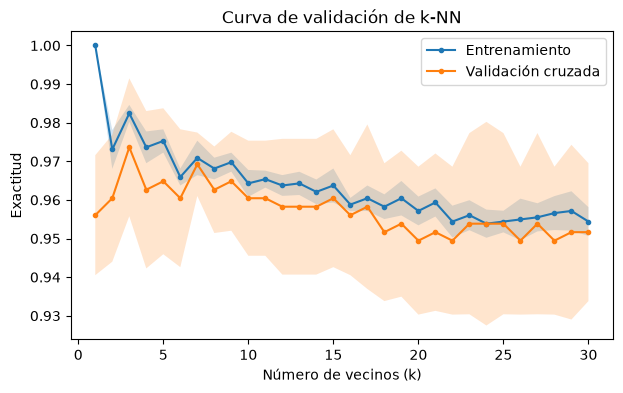

k = 1:  entrenamiento 1.000 | validación 0.956
k = 3:  entrenamiento 0.982 | validación 0.974


In [5]:
valores_k = np.arange(1, 31)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier())
puntos_train, puntos_val = validation_curve(
    knn, X_train, y_train, param_name="kneighborsclassifier__n_neighbors",
    param_range=valores_k, cv=cv)

fig, ax = plt.subplots(figsize=(7, 4))
for puntos, nombre in [(puntos_train, "Entrenamiento"), (puntos_val, "Validación cruzada")]:
    media, desv = puntos.mean(axis=1), puntos.std(axis=1)
    ax.plot(valores_k, media, marker=".", label=nombre)
    ax.fill_between(valores_k, media - desv, media + desv, alpha=0.2)
ax.set_xlabel("Número de vecinos (k)")
ax.set_ylabel("Exactitud")
ax.set_title("Curva de validación de k-NN")
ax.legend()
plt.show()

print(f"k = 1:  entrenamiento {puntos_train[0].mean():.3f} | validación {puntos_val[0].mean():.3f}")
mejor = puntos_val.mean(axis=1).argmax()
print(f"k = {valores_k[mejor]}:  entrenamiento {puntos_train[mejor].mean():.3f} | validación {puntos_val[mejor].mean():.3f}")

- Con $k = 1$ la exactitud en entrenamiento es perfecta (cada punto es su propio vecino), pero en validación es menor: **sobreajuste**.
- Al aumentar $k$, la diferencia entre las dos curvas se reduce. Con $k$ muy grande, ambas bajan poco a poco: el modelo empieza a ser demasiado simple (**subajuste**).
- Las bandas sombreadas (± una desviación típica) muestran que muchos valores de $k$ son estadísticamente equivalentes.

### 3.4. Búsqueda de hiperparámetros con `GridSearchCV`

`GridSearchCV` automatiza la búsqueda: prueba cada combinación de hiperparámetros con validación cruzada y se queda con la mejor. Al final reentrena el mejor modelo con todo el entrenamiento:

In [6]:
rejilla = GridSearchCV(knn, {"kneighborsclassifier__n_neighbors": list(valores_k)}, cv=cv)
rejilla.fit(X_train, y_train)

resultados = (pd.DataFrame(rejilla.cv_results_)
              .sort_values("rank_test_score")
              [["param_kneighborsclassifier__n_neighbors", "mean_test_score", "std_test_score"]]
              .rename(columns={"param_kneighborsclassifier__n_neighbors": "k",
                               "mean_test_score": "media", "std_test_score": "desviación"}))
print(f"Mejor k: {rejilla.best_params_['kneighborsclassifier__n_neighbors']} "
      f"(exactitud en validación cruzada: {rejilla.best_score_:.3f})")
resultados.head(5).round(4)

Mejor k: 3 (exactitud en validación cruzada: 0.974)


,k,media,desviación
2,3,0.9736,0.0179
6,7,0.9692,0.0082
4,5,0.9648,0.0189
8,9,0.9648,0.0128
3,4,0.9626,0.0204


Los mejores valores de $k$ se diferencian en unas milésimas, mucho menos que su desviación típica (≈ 0,01–0,02). **El "ganador" podría ser otro con una semilla distinta**. Ante un empate así, conviene elegir el modelo más simple o más estable (aquí, un $k$ algo mayor, con la frontera más suave y menos desviación), en lugar del primero de la lista.

### 3.5. Evaluación final en el conjunto de prueba

Solo ahora usamos el conjunto de prueba, una vez, con el modelo elegido. Aquí evaluamos la regresión logística: en validación cruzada empataba con el mejor k-NN (0,974), pero es un modelo más simple y con menos variación entre particiones (0,015 frente a 0,018), así que ante el empate la preferimos:

              precision    recall  f1-score   support

     benigno      0.959     0.986     0.973        72
     maligno      0.975     0.929     0.951        42

    accuracy                          0.965       114
   macro avg      0.967     0.957     0.962       114
weighted avg      0.965     0.965     0.965       114



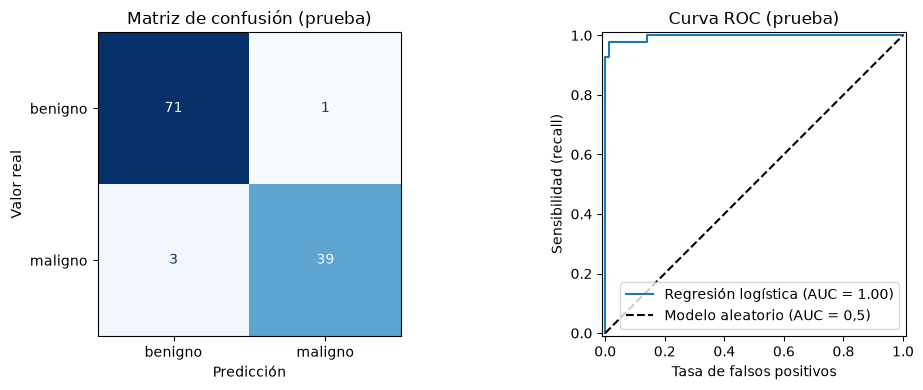

In [7]:
logistica.fit(X_train, y_train)
y_pred = logistica.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["benigno", "maligno"], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["benigno", "maligno"],
                                        cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión (prueba)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")
RocCurveDisplay.from_estimator(logistica, X_test, y_test, ax=axes[1], name="Regresión logística")
axes[1].plot([0, 1], [0, 1], "k--", label="Modelo aleatorio (AUC = 0,5)")
axes[1].set_title("Curva ROC (prueba)")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Sensibilidad (recall)")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

- La exactitud en prueba (96,5 %) es coherente con la estimada en la validación cruzada (97,4 %): el modelo no estaba sobreajustado.
- La matriz de confusión muestra **3 falsos negativos**: 3 tumores malignos clasificados como benignos. En un diagnóstico, ese es el error caro. El recall de la clase "maligno" (0,929) importa más que la exactitud global.
- El AUC de 0,996 (la leyenda lo redondea a 1,00) indica que el modelo ordena casi perfectamente los casos por probabilidad de malignidad. Ajustar el umbral de decisión permitiría cambiar falsos negativos por falsos positivos (ver [ajuste del umbral](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb)).

### 3.6. Métricas de regresión

En *diabetes* comparamos cuatro modelos. El `DummyRegressor`, que predice siempre la media, sirve de **línea base**: cualquier modelo útil debe superarlo.

In [8]:
X_diab, y_diab = load_diabetes(return_X_y=True)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)

regresores = {
    "Línea base (media)": DummyRegressor(),
    "Regresión lineal": LinearRegression(),
    "Árbol sin límite": DecisionTreeRegressor(random_state=42),
    "Árbol (profundidad 3)": DecisionTreeRegressor(max_depth=3, random_state=42),
}
filas = []
for nombre, modelo in regresores.items():
    pred = modelo.fit(Xd_train, yd_train).predict(Xd_test)
    filas.append({"modelo": nombre, "MAE": mean_absolute_error(yd_test, pred),
                  "RMSE": root_mean_squared_error(yd_test, pred), "R²": r2_score(yd_test, pred)})
pd.DataFrame(filas).set_index("modelo").round(3)

,MAE,RMSE,R²
modelo,,,
Línea base (media),64.006,73.222,-0.012
Regresión lineal,42.794,53.853,0.453
Árbol sin límite,54.528,70.546,0.061
Árbol (profundidad 3),48.097,59.605,0.329


- La línea base tiene un $R^2$ ≈ 0 (ligeramente negativo en prueba), como corresponde a predecir la media.
- La regresión lineal explica un 45 % de la variabilidad y reduce el error absoluto medio de 64 a 43.
- El árbol sin límite de profundidad sobreajusta y apenas mejora la línea base ($R^2$ = 0,06). Limitarlo a profundidad 3 lo mejora mucho, aunque sigue por debajo del modelo lineal en este problema.
- El RMSE es siempre mayor o igual que el MAE: penaliza más los errores grandes.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Función / clase | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `train_test_split` | `test_size`, `stratify`, `shuffle` | Tamaño de la prueba, estratificación, orden | `stratify=y` en clasificación; `shuffle=False` solo con datos temporales |
| `StratifiedKFold` / `KFold` | `n_splits`, `shuffle`, `random_state` | Nº de partes y si se barajan | 5 o 10 partes; `shuffle=True` si los datos vienen ordenados |
| `cross_val_score` / `cross_validate` | `cv`, `scoring` | Estrategia de partición y métrica | Con un entero en clasificación usa `StratifiedKFold` **sin barajar** |
| `GridSearchCV` | `param_grid`, `scoring`, `refit` | Rejilla, métrica y si reentrena el mejor | Nombres de parámetros con el prefijo del paso del `Pipeline` (`paso__parametro`) |
| `RandomizedSearchCV` | `n_iter`, `param_distributions` | Nº de combinaciones al azar | Mejor que la rejilla cuando hay muchos hiperparámetros |
| `validation_curve` / `learning_curve` | `param_range` / `train_sizes` | Rendimiento frente a un hiperparámetro o al tamaño del entrenamiento | Para diagnosticar sobreajuste o falta de datos |
| Métricas | `average` | `"macro"`, `"weighted"`, `"micro"` en varias clases | `"macro"` para que cada clase cuente igual |

### 4.2. Errores comunes

Varias de estas lecciones salen de trabajo real con clasificadores de *malware* y de éxito comercial de videojuegos, de un clasificador del estado de turbinas y de un problema de regresión con árboles.

**1. Evaluar con los datos de entrenamiento.** Un árbol de decisión sin límites alcanzó una exactitud y un $F_1$ de prácticamente 1 en entrenamiento, muy por encima de los de prueba: memorizaba el entrenamiento. Limitar su profundidad y tamaño mínimo de nodo con búsqueda de hiperparámetros dejó entrenamiento y prueba en valores parecidos (≈ 0,71 y 0,69 de exactitud). El rendimiento en entrenamiento **no es** una estimación del rendimiento real:

In [9]:
arbol = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f"Árbol sin límite, exactitud en entrenamiento: {accuracy_score(y_train, arbol.predict(X_train)):.3f}")
print(f"Árbol sin límite, validación cruzada:         {cross_val_score(DecisionTreeClassifier(random_state=42), X_train, y_train, cv=cv).mean():.3f}")

Árbol sin límite, exactitud en entrenamiento: 1.000
Árbol sin límite, validación cruzada:         0.923


**2. Elegir hiperparámetros mirando el conjunto de prueba, o informar de `best_score_` como rendimiento final.** Si se prueban muchos valores y se informa del mejor, esa cifra es optimista: se ha elegido precisamente porque salió bien en esas particiones. El conjunto de prueba debe quedar fuera de la búsqueda. Para estimar sin sesgo el rendimiento de "buscar y entrenar", se usa la **validación cruzada anidada** (*nested cross-validation*): una validación cruzada externa en la que cada iteración ejecuta su propia búsqueda interna:

In [10]:
cv_externa = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
anidada = cross_val_score(rejilla, X_train, y_train, cv=cv_externa)

print(f"best_score_ de la búsqueda:       {rejilla.best_score_:.3f}")
print(f"Validación cruzada anidada:       {anidada.mean():.3f}")
print(f"Exactitud en prueba del mejor k-NN: {rejilla.score(X_test, y_test):.3f}")

best_score_ de la búsqueda:       0.974
Validación cruzada anidada:       0.963
Exactitud en prueba del mejor k-NN: 0.939


La mejor puntuación de la búsqueda es la más alta de las tres. La anidada es más prudente y está más cerca de lo que el modelo consigue después con datos nuevos.

**3. Leer la clasificación de `GridSearchCV` como si las diferencias fueran reales.** En la búsqueda del número de vecinos de un k-NN, los mejores valores ($k$ = 5 y $k$ = 7) se diferenciaban en **0,0005** de exactitud, con una desviación típica de **0,006** entre particiones. Esa diferencia es ruido. Mira siempre `std_test_score` junto a `mean_test_score` (3.4), y ante un empate elige el modelo más simple.

**4. Partir datos ordenados sin barajar y pedirle al modelo que extrapole.** En un problema de regresión con los datos ordenados por la variable de entrada, el último 20 % se usó como prueba. Un árbol de decisión dio un $R^2$ de **0,9999 en entrenamiento y −1,62 en prueba**: peor que predecir la media. Los árboles predicen con valores vistos en el entrenamiento, así que **no pueden extrapolar** fuera de ese rango. Reproducimos el efecto con datos propios: una relación lineal, entrenando con $x < 8$ y probando con $x \geq 8$:

In [11]:
rng = np.random.default_rng(42)
x = np.sort(rng.uniform(0, 10, 200))
y_lineal = 3 * x + rng.normal(0, 1, 200)
es_train = x < 8

for nombre, modelo in [("Árbol de decisión", DecisionTreeRegressor(random_state=42)),
                       ("Regresión lineal", LinearRegression())]:
    modelo.fit(x[es_train, None], y_lineal[es_train])
    r2_tr = r2_score(y_lineal[es_train], modelo.predict(x[es_train, None]))
    r2_te = r2_score(y_lineal[~es_train], modelo.predict(x[~es_train, None]))
    print(f"{nombre:18s}  R² entrenamiento: {r2_tr:6.3f} | R² prueba (x ≥ 8): {r2_te:6.3f}")

Árbol de decisión   R² entrenamiento:  1.000 | R² prueba (x ≥ 8): -3.602
Regresión lineal    R² entrenamiento:  0.980 | R² prueba (x ≥ 8):  0.628


El árbol predice como mucho el último valor que vio, y su $R^2$ en prueba es muy negativo. La regresión lineal sí extrapola la tendencia. Si la partición no es aleatoria, porque los datos son temporales o están ordenados, la prueba mide la capacidad de **extrapolar**, y hay que elegir el modelo en consecuencia.

**5. Preprocesar fuera del `Pipeline`.** Escalar, imputar o codificar con todos los datos antes de la validación cruzada filtra información de las particiones de validación (ver [limpieza de datos](../03-preparacion-datos/02-limpieza-datos.ipynb) y [transformación](../03-preparacion-datos/03-transformacion-datos.ipynb)). En un clasificador del estado de turbinas se hizo bien: el `ColumnTransformer` (one-hot más escalado) formaba parte del `Pipeline`, y `GridSearchCV` lo reajustaba en cada partición.

**6. Elegir la métrica sin pensar en el objetivo.** En ese mismo clasificador de turbinas, con tres estados y desbalanceo moderado (50 %, 30 % y 20 %), se eligió el **$F_1$ macro**: cada estado cuenta igual, y el mayoritario ("funcionamiento normal") no domina. En el clasificador de *malware*, el error caro era el falso negativo (*malware* no detectado), así que el recall importaba más que la exactitud. La métrica se decide en la fase de comprensión del negocio, no después de ver los resultados.

## 5. Comparación con métodos relacionados

### 5.1. Estrategias de validación

| Estrategia | Nº de entrenamientos | Cuándo usarla | Inconvenientes |
|---|---|---|---|
| Partición simple (*hold-out*) | 1 | Muchos datos (cientos de miles) | Estimación ruidosa con pocos datos |
| k-fold (estratificado) | $k$ (5–10) | Opción por defecto | Coste $k$ veces mayor |
| k-fold repetido | $k \times r$ | Estimaciones más estables con pocos datos | Más coste |
| Leave-One-Out | $n$ | Muy pocos datos | Muy costoso; estimación con más varianza |
| Leave-p-Out | $\binom{n}{p}$ | Casi nunca | Número de combinaciones intratable |
| Partición temporal | Varios, ventana creciente | Series temporales | No baraja; solo valida hacia el futuro |
| Validación cruzada anidada | $k_\text{ext} \times k_\text{int} \times$ combinaciones | Estimar sin sesgo un modelo con búsqueda de hiperparámetros | Muy costosa |

### 5.2. Qué métrica usar

| Situación | Métrica recomendada |
|---|---|
| Clases equilibradas, todos los errores cuestan igual | Exactitud |
| Falsos negativos caros (diagnóstico, fraude) | Recall (con una precisión mínima) |
| Falsos positivos caros (filtro de spam, alertas) | Precisión |
| Equilibrio entre ambos, clases desbalanceadas | $F_1$ de la clase minoritaria, $F_1$ macro |
| Comparar modelos independientemente del umbral | ROC-AUC; PR-AUC si hay desbalanceo fuerte |
| Regresión, errores en unidades interpretables | MAE; RMSE si los errores grandes son especialmente graves |
| Regresión, comparar con la línea base | $R^2$ |

## 6. Referencias

### Fuentes

- scikit-learn: [*Cross-validation: evaluating estimator performance*](https://scikit-learn.org/stable/modules/cross_validation.html), [*Tuning the hyper-parameters of an estimator*](https://scikit-learn.org/stable/modules/grid_search.html) y [*Metrics and scoring*](https://scikit-learn.org/stable/modules/model_evaluation.html).
- Datasets: [breast_cancer y diabetes en scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html). *breast_cancer* procede del conjunto *Breast Cancer Wisconsin (Diagnostic)* del repositorio UCI.

### Para saber más

- Hastie, T., Tibshirani, R. y Friedman, J. (2009). *The Elements of Statistical Learning* (2.ª ed.). Springer. Capítulo 7: evaluación y selección de modelos, sesgo y varianza, validación cruzada.
- Kohavi, R. (1995). *A Study of Cross-Validation and Bootstrap for Accuracy Estimation and Model Selection*. En *Proceedings of the 14th International Joint Conference on Artificial Intelligence (IJCAI)*, 1137–1145. Por qué 10-fold suele ser preferible a Leave-One-Out.